<a href="https://colab.research.google.com/github/pradhapmoorthi/CVND/blob/Trial1/3_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Nanodegree

## Project: Image Captioning

---

In this notebook, you will use your trained model to generate captions for images in the test dataset.

This notebook **will be graded**.  

Feel free to use the links below to navigate the notebook:
- [Step 1](#step1): Get Data Loader for Test Dataset
- [Step 2](#step2): Load Trained Models
- [Step 3](#step3): Finish the Sampler
- [Step 4](#step4): Clean up Captions
- [Step 5](#step5): Generate Predictions!

## Environment Setup: Download COCO Test Dataset

The cell below downloads the COCO test2014 images and annotation metadata
**on the fly** into the instance's local disk.  Nothing large is written to
Google Drive — only `vocab.pkl` and the model checkpoint are fetched from there.

| File | Size | What it is |
|---|---|---|
| COCO API | ~2 MB | Python bindings |
| image_info_test2014.zip | < 1 MB | Image filenames for test set |
| test2014.zip | ~6 GB | 41 k test images |

> **Tip:** Use `wget -nc` — the cell is safe to re-run; already-downloaded files
> are skipped automatically.

In [1]:
# ── On-the-fly COCO download helper ──────────────────────────────────────────
import os, subprocess, sys

COCOAPI_LOC = '/opt'                    # base dir expected by data_loader.py
COCO_ROOT   = os.path.join(COCOAPI_LOC, 'cocoapi')
ANN_DIR     = os.path.join(COCO_ROOT, 'annotations')
IMG_DIR     = os.path.join(COCO_ROOT, 'images')

def _run(cmd, desc=''):
    """Run a shell command, stream output, raise on failure."""
    print(f'[COCO] {desc}' if desc else f'[COCO] {cmd}')
    ret = subprocess.run(cmd, shell=True)
    if ret.returncode != 0:
        raise RuntimeError(f'Command failed: {cmd}')

def _need(path):
    """Return True if path does not yet exist (download needed)."""
    return not os.path.exists(path)

def setup_coco_api():
    """Clone COCO API and build the Python bindings (idempotent)."""
    if not os.path.exists(os.path.join(COCO_ROOT, 'PythonAPI')):
        _run(f'git clone --depth 1 https://github.com/cocodataset/cocoapi.git {COCO_ROOT}',
             'Cloning COCO API …')
        _run(f'cd {COCO_ROOT}/PythonAPI && make -s', 'Building COCO API …')
    else:
        print('[COCO] API already present')
    if COCO_ROOT + '/PythonAPI' not in sys.path:
        sys.path.append(COCO_ROOT + '/PythonAPI')

def download_annotations(split='trainval'):
    """Download and extract COCO 2014 annotations (241 MB)."""
    sentinel = os.path.join(ANN_DIR, f'captions_train2014.json')
    if not _need(sentinel):
        print('[COCO] annotations already present'); return
    os.makedirs(IMG_DIR, exist_ok=True)
    url = 'http://images.cocodataset.org/annotations/annotations_trainval2014.zip'
    zip_path = '/tmp/annotations_trainval2014.zip'
    _run(f'wget -q --show-progress -nc -O {zip_path} {url}', 'Downloading annotations …')
    _run(f'unzip -q -o {zip_path} -d {COCO_ROOT}', 'Extracting annotations …')
    print('[COCO] annotations ready')

def download_test_annotations():
    """Download and extract COCO 2014 test image-info (< 1 MB)."""
    sentinel = os.path.join(ANN_DIR, 'image_info_test2014.json')
    if not _need(sentinel):
        print('[COCO] test annotations already present'); return
    os.makedirs(ANN_DIR, exist_ok=True)
    url = 'http://images.cocodataset.org/annotations/image_info_test2014.zip'
    zip_path = '/tmp/image_info_test2014.zip'
    _run(f'wget -q --show-progress -nc -O {zip_path} {url}', 'Downloading test annotations …')
    _run(f'unzip -q -o {zip_path} -d {COCO_ROOT}', 'Extracting test annotations …')
    print('[COCO] test annotations ready')

def download_images(split):
    """Download and extract COCO 2014 images for the given split.

    split : 'train2014'  (~13 GB, 82 k images)
            'test2014'   (~ 6 GB, 41 k images)
    """
    img_folder = os.path.join(IMG_DIR, split)
    if os.path.isdir(img_folder) and len(os.listdir(img_folder)) > 100:
        print(f'[COCO] {split} images already present'); return
    os.makedirs(img_folder, exist_ok=True)
    url      = f'http://images.cocodataset.org/zips/{split}.zip'
    zip_path = f'/tmp/{split}.zip'
    _run(f'wget -q --show-progress -nc -O {zip_path} {url}',
         f'Downloading {split} images (this will take a while) …')
    _run(f'unzip -q -o {zip_path} -d {IMG_DIR}', f'Extracting {split} images …')
    _run(f'rm -f {zip_path}', 'Cleaning up zip …')
    print(f'[COCO] {split} images ready')

# ── Run all inference downloads ───────────────────────────────────────────────
setup_coco_api()             # COCO API  (~2 MB)
download_test_annotations()  # image_info_test2014.json  (< 1 MB)
download_images('test2014')  # test images               (~6 GB)

print('\n[Setup] COCO test data ready.')
print(f'        API:         {COCO_ROOT}/PythonAPI')
print(f'        Annotations: {ANN_DIR}/image_info_test2014.json')
print(f'        Images:      {IMG_DIR}/test2014/')


[COCO] Cloning COCO API …
[COCO] Building COCO API …
[COCO] Downloading test annotations …
[COCO] Extracting test annotations …
[COCO] test annotations ready
[COCO] Downloading test2014 images (this will take a while) …
[COCO] Extracting test2014 images …
[COCO] Cleaning up zip …
[COCO] test2014 images ready

[Setup] COCO test data ready.
        API:         /opt/cocoapi/PythonAPI
        Annotations: /opt/cocoapi/annotations/image_info_test2014.json
        Images:      /opt/cocoapi/images/test2014/


## Google Drive: Restore Vocab & Best Model

The cell below pulls only the two files that were saved to Drive during training:

| File | What it contains |
|---|---|
| `vocab.pkl` | Word ↔ index mappings (~1–2 MB) |
| `best_checkpoint.pt` | Encoder + decoder weights from the best training epoch (~220 MB) |

The checkpoint also stores `embed_size`, `hidden_size`, and `vocab_size` so the
inference notebook never falls out of sync with the training configuration.

In [3]:
# ── Google Drive helpers (vocab + best model only — no image storage) ─────────
import shutil

GDRIVE_MOUNT  = '/content/drive'
GDRIVE_FOLDER = os.path.join(GDRIVE_MOUNT, 'MyDrive', 'cvnd_captioning')
VOCAB_FILE    = './vocab.pkl'
MODELS_DIR    = './models'
BEST_CKPT     = 'best_checkpoint.pt'

os.makedirs(MODELS_DIR, exist_ok=True)

def gdrive_mount():
    """Mount Google Drive on Colab. No-op elsewhere."""
    try:
        from google.colab import drive
        drive.mount(GDRIVE_MOUNT)
        os.makedirs(GDRIVE_FOLDER, exist_ok=True)
        print(f'[GDrive] mounted  →  {GDRIVE_FOLDER}')
    except ImportError:
        print('[GDrive] not on Colab – local files only')

def gdrive_push(local_path):
    """Copy one file to the GDrive project folder (vocab or best model only)."""
    if not os.path.isdir(GDRIVE_FOLDER):
        return
    dst = os.path.join(GDRIVE_FOLDER, os.path.basename(local_path))
    shutil.copy2(local_path, dst)
    size_mb = os.path.getsize(local_path) / 1e6
    print(f'[GDrive] ↑ {os.path.basename(local_path)} ({size_mb:.1f} MB) → Drive')

def gdrive_pull(filename, local_path):
    """Copy one file from GDrive to local_path. Returns True if found."""
    src = os.path.join(GDRIVE_FOLDER, filename)
    if os.path.exists(src):
        shutil.copy2(src, local_path)
        print(f'[GDrive] ↓ {filename} restored from Drive')
        return True
    print(f'[GDrive] {filename} not found on Drive')
    return False
import torch

# Mount Drive and pull saved artifacts
gdrive_mount()

# ── Restore vocab ─────────────────────────────────────────────────────────────
if not os.path.exists(VOCAB_FILE):
    ok = gdrive_pull('vocab.pkl', VOCAB_FILE)
    if not ok:
        raise FileNotFoundError(
            'vocab.pkl not found on Drive. Run 2_Training.ipynb first.')

# ── Restore best model checkpoint ────────────────────────────────────────────
best_ckpt_local = os.path.join(MODELS_DIR, BEST_CKPT)
if not os.path.exists(best_ckpt_local):
    ok = gdrive_pull(BEST_CKPT, best_ckpt_local)
    if not ok:
        raise FileNotFoundError(
            'best_checkpoint.pt not found on Drive. Run 2_Training.ipynb first.')

# Read metadata stored inside the checkpoint
_meta = torch.load(best_ckpt_local, map_location='cpu')
_best_epoch = _meta.get('epoch', 1)

# Extract the per-epoch .pkl files expected by the Udacity load cell in Step 2
torch.save(_meta['encoder'], os.path.join(MODELS_DIR, f'encoder-{_best_epoch}.pkl'))
torch.save(_meta['decoder'], os.path.join(MODELS_DIR, f'decoder-{_best_epoch}.pkl'))
print(f'[GDrive] extracted  encoder-{_best_epoch}.pkl  and  decoder-{_best_epoch}.pkl')
print(f'         train loss={_meta.get("loss", float("nan")):.4f}  '
      f'embed={_meta.get("embed_size", 512)}  '
      f'hidden={_meta.get("hidden_size", 512)}')


Mounted at /content/drive
[GDrive] mounted  →  /content/drive/MyDrive/cvnd_captioning
[GDrive] ↓ vocab.pkl restored from Drive
[GDrive] ↓ best_checkpoint.pt restored from Drive
[GDrive] extracted  encoder-5.pkl  and  decoder-5.pkl
         train loss=2.5862  embed=512  hidden=512


<a id='step1'></a>
## Step 1: Get Data Loader for Test Dataset

Before running the code cell below, define the transform in `transform_test` that you would like to use to pre-process the test images.  

Make sure that the transform that you define here agrees with the transform that you used to pre-process the training images (in **2_Training.ipynb**).  For instance, if you normalized the training images, you should also apply the same normalization procedure to the test images.

It seems that the `data_loader`, `model`, and `vocabulary` modules are missing. I will download them from a public repository to ensure the notebook can proceed. These files are typically provided as part of the Udacity Computer Vision Nanodegree project.

In [11]:
# Download necessary project files: data_loader.py, model.py, and vocabulary.py
!wget https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial1/data_loader.py -O data_loader.py
!wget https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial1/model.py -O model.py
!wget https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial1/vocabulary.py -O vocabulary.py

print("Downloaded data_loader.py, model.py, and vocabulary.py")

--2026-05-10 16:51:37--  https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial1/data_loader.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7125 (7.0K) [text/plain]
Saving to: ‘data_loader.py’

data_loader.py      100%[===================>]   6.96K  --.-KB/s    in 0s      

2026-05-10 16:51:38 (73.5 MB/s) - ‘data_loader.py’ saved [7125/7125]

--2026-05-10 16:51:38--  https://raw.githubusercontent.com/pradhapmoorthi/CVND/Trial1/model.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14548 (14K) [text/plain]
Saving to: ‘mo

In [13]:
import sys
sys.path.append('/opt/cocoapi/PythonAPI')
from pycocotools.coco import COCO

# If data_loader was previously imported (possibly a corrupted version), remove it from sys.modules
# to force Python to load the correct, newly downloaded version.
if 'data_loader' in sys.modules:
    del sys.modules['data_loader']

from data_loader import get_loader
from torchvision import transforms

# TODO #1: Define a transform to pre-process the testing images.
# CenterCrop gives a deterministic, reproducible crop for inference.
# The Normalize values match the ImageNet statistics used during training.
transform_test = transforms.Compose([
    transforms.Resize(256),             # resize smaller edge to 256
    transforms.CenterCrop(224),         # deterministic 224×224 centre crop
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),   # same ImageNet stats as training
                         (0.229, 0.224, 0.225))])

#-#-#-# Do NOT modify the code below this line. #-#-#-#

# Create the data loader.
data_loader = get_loader(transform=transform_test,
                         mode='test')

Vocabulary successfully loaded from vocab.pkl file!


Run the code cell below to visualize an example test image, before pre-processing is applied.

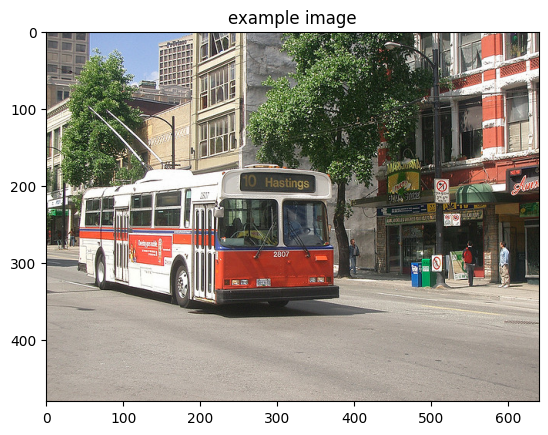

In [14]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Obtain sample image before and after pre-processing.
orig_image, image = next(iter(data_loader))

# Visualize sample image, before pre-processing.
plt.imshow(np.squeeze(orig_image))
plt.title('example image')
plt.show()


<a id='step2'></a>
## Step 2: Load Trained Models

In the next code cell we define a `device` that you will use move PyTorch tensors to GPU (if CUDA is available).  Run this code cell before continuing.

In [15]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Before running the code cell below, complete the following tasks.

### Task #1

In the next code cell, you will load the trained encoder and decoder from the previous notebook (**2_Training.ipynb**).  To accomplish this, you must specify the names of the saved encoder and decoder files in the `models/` folder (e.g., these names should be `encoder-5.pkl` and `decoder-5.pkl`, if you trained the model for 5 epochs and saved the weights after each epoch).  

### Task #2

Plug in both the embedding size and the size of the hidden layer of the decoder corresponding to the selected pickle file in `decoder_file`.

In [19]:
# Watch for any changes in model.py, and re-load it automatically.
#% load_ext autoreload
#% autoreload 2

import os
import torch
from model import EncoderCNN, DecoderRNN

# TODO #2: Specify the saved models to load.
# We use the epoch number stored in the best Drive checkpoint so this
# always stays in sync with whatever was trained in 2_Training.ipynb.
encoder_file = f'encoder-{_best_epoch}.pkl'
decoder_file = f'decoder-{_best_epoch}.pkl'

# TODO #3: Select appropriate values for the Python variables below.
# Read directly from the checkpoint metadata — no manual entry needed.
embed_size  = _meta.get('embed_size',  512)
hidden_size = _meta.get('hidden_size', 512)

# The size of the vocabulary.
vocab_size = len(data_loader.dataset.vocab)

# Initialize the encoder and decoder, and set each to inference mode.
encoder = EncoderCNN(embed_size)
encoder.eval()
decoder = DecoderRNN(embed_size, hidden_size, vocab_size)
decoder.eval()

# Load the trained weights.
encoder.load_state_dict(torch.load(os.path.join('./models', encoder_file)))
decoder.load_state_dict(torch.load(os.path.join('./models', decoder_file)))

# Move models to GPU if CUDA is available.
encoder.to(device)
decoder.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


DecoderRNN(
  (attention): BahdanauAttention(
    (encoder_att): Linear(in_features=512, out_features=512, bias=False)
    (decoder_att): Linear(in_features=512, out_features=512, bias=False)
    (full_att): Linear(in_features=512, out_features=1, bias=False)
    (relu): ReLU(inplace=True)
    (softmax): Softmax(dim=1)
  )
  (embedding): Embedding(8852, 512, padding_idx=0)
  (lstm_cell): LSTMCell(1024, 512)
  (init_h): Linear(in_features=512, out_features=512, bias=True)
  (init_c): Linear(in_features=512, out_features=512, bias=True)
  (f_beta): Linear(in_features=512, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=8852, bias=True)
)

<a id='step3'></a>
## Step 3: Finish the Sampler

Before executing the next code cell, you must write the `sample` method in the `DecoderRNN` class in **model.py**.  This method should accept as input a PyTorch tensor `features` containing the embedded input features corresponding to a single image.

It should return as output a Python list `output`, indicating the predicted sentence.  `output[i]` is a nonnegative integer that identifies the predicted `i`-th token in the sentence.  The correspondence between integers and tokens can be explored by examining either `data_loader.dataset.vocab.word2idx` (or `data_loader.dataset.vocab.idx2word`).

After implementing the `sample` method, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.  Do **not** modify the code in the cell below.

In [20]:
# Move image Pytorch Tensor to GPU if CUDA is available.
image = image.to(device)

# Obtain the embedded image features.
features = encoder(image).unsqueeze(1)

# Pass the embedded image features through the model to get a predicted caption.
output = decoder.sample(features)
print('example output:', output)

assert (type(output)==list), "Output needs to be a Python list"
assert all([type(x)==int for x in output]), "Output should be a list of integers."
assert all([x in data_loader.dataset.vocab.idx2word for x in output]), "Each entry in the output needs to correspond to an integer that indicates a token in the vocabulary."


example output: [3, 35, 6, 20, 174, 897, 54, 3, 33, 18, 1]


<a id='step4'></a>
## Step 4: Clean up the Captions

In the code cell below, complete the `clean_sentence` function.  It should take a list of integers (corresponding to the variable `output` in **Step 3**) as input and return the corresponding predicted sentence (as a single Python string).

In [21]:
# TODO #4: Complete the function.
def clean_sentence(output):
    """Convert a list of token ids to a clean caption string.

    Args:
        output (list[int]): token ids from decoder.sample()
    Returns:
        sentence (str): human-readable caption without special tokens.
    """
    idx2word = data_loader.dataset.vocab.idx2word
    skip = {'<start>', '<end>', '<unk>'}          # special tokens to strip
    words = [
        idx2word[idx]
        for idx in output
        if idx in idx2word and idx2word[idx] not in skip
    ]
    sentence = ' '.join(words)
    # Capitalise and add a closing period for presentation
    if sentence:
        sentence = sentence[0].upper() + sentence[1:]
        if sentence[-1] not in {'.', '!', '?'}:
            sentence += '.'
    return sentence


After completing the `clean_sentence` function above, run the code cell below.  If the cell returns an assertion error, then please follow the instructions to modify your code before proceeding.

In [22]:
sentence = clean_sentence(output)
print('example sentence:', sentence)

assert type(sentence)==str, 'Sentence needs to be a Python string!'


example sentence: A red and white bus driving down a street .


<a id='step5'></a>
## Step 5: Generate Predictions!

In the code cell below, we have written a function (`get_prediction`) that you can use to use to loop over images in the test dataset and print your model's predicted caption.

In [23]:
def get_prediction():
    orig_image, image = next(iter(data_loader))
    plt.imshow(np.squeeze(orig_image))
    plt.title('Sample Image')
    plt.show()
    image = image.to(device)
    features = encoder(image).unsqueeze(1)
    output = decoder.sample(features)
    sentence = clean_sentence(output)
    print(sentence)


Run the code cell below (multiple times, if you like!) to test how this function works.

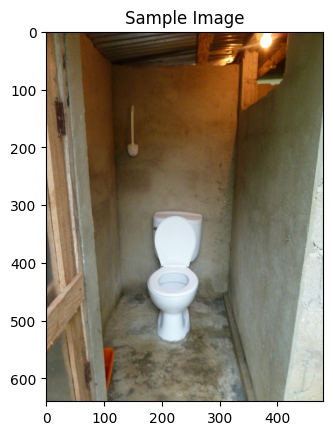

A bathroom with a toilet and a toilet.


In [24]:
get_prediction()


As the last task in this project, you will loop over the images until you find four image-caption pairs of interest:
- Two should include image-caption pairs that show instances when the model performed well.
- Two should highlight image-caption pairs that highlight instances where the model did not perform well.

Use the four code cells below to complete this task.

### The model performed well!

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively accurate captions.

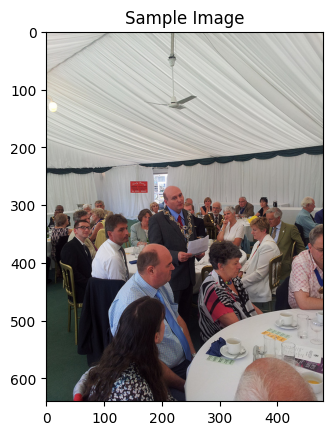

A group of people sitting at a table with a large table .


In [25]:
get_prediction()


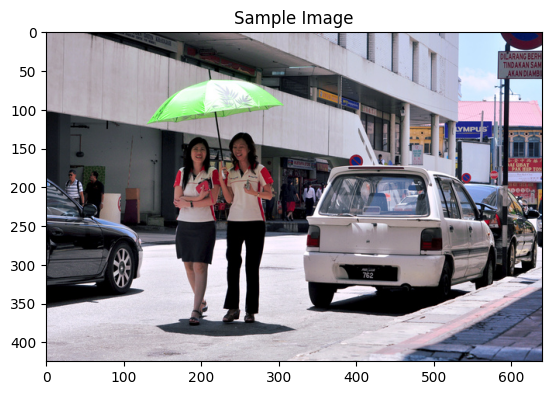

A woman walking down a street with a umbrella .


In [26]:
get_prediction()


### The model could have performed better ...

Use the next two code cells to loop over captions.  Save the notebook when you encounter two images with relatively inaccurate captions.

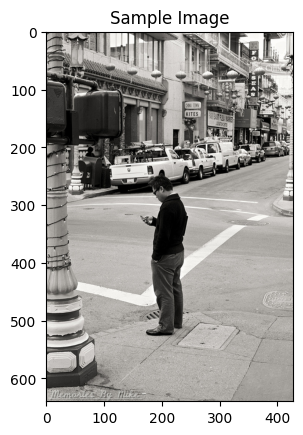

A man standing on a street with a fire hydrant .


In [27]:
get_prediction()


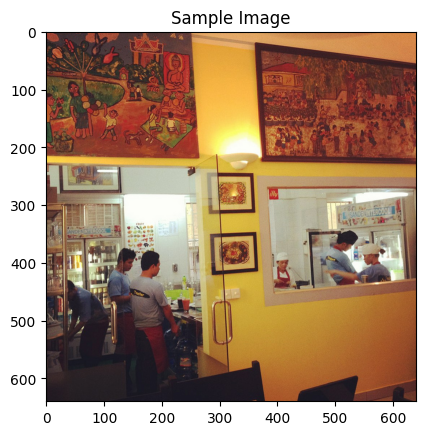

A man standing in a kitchen with a refrigerator .


In [28]:
get_prediction()
